# Measuring angular power spectra with NaMaster

In this notebook, we simulate a galaxy catalogue containing right ascension, declination, and redshift, together with a catalogue of gravitational-wave events.

We convert both catalogues into HEALPix overdensity maps and use the `NaMaster` package to measure

\begin{align}
C_\ell^{\mathrm{g}\times \mathrm{g}},
\qquad
C_\ell^{\mathrm{GW}\times \mathrm{GW}},
\qquad
C_\ell^{\mathrm{g}\times\mathrm{GW}},
\end{align}

corresponding to the galaxy auto-spectrum, gravitational-wave auto-spectrum, and galaxy–gravitational-wave cross-spectrum.


---

## 1. Simulation settings

We first specify the HEALPix resolution, the number of simulated galaxies and gravitational-wave events, the redshift range, and the multipole bin width.

The HEALPix resolution is controlled by `NSIDE`. The largest useful multipole is approximately

\begin{align}
\ell_{\max} \simeq 3\mathrm{NSIDE}-1.
\end{align}

---


In [2]:
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt
import pandas as pd
rng = np.random.default_rng(42)
nside = 128
npix = hp.nside2npix(nside)

Ngw = 20000

zmin, zmax = 0., 0.5
delta_ell = 20


## 2. Simulating the galaxy catalogue and gravitational-wave events

We will use a 1/128 subsample of the MICEcat galaxy sample up to redshift $z=0.5$, where I have downloaded the columns:

\begin{align}
(\mathrm{RA},\mathrm{Dec},z).
\end{align}

We then select the gravitational-wave hosts from the simulated galaxy catalogue. 

---

In [3]:

catalog_filename = "/Users/maddycrossparkin/Downloads/SwinNaMasterData.csv.bz2"
chunksize = 10000
chunks = []
columns_needed = ['ra', 'dec', 'z']

for chunk in pd.read_csv(catalog_filename, sep=",", comment='#', na_values=r'\N', compression='bz2', chunksize=chunksize, usecols = columns_needed):
    chunks.append(chunk)

data_MICECAT = pd.concat(chunks, ignore_index=True)
ra_gal = data_MICECAT['ra'].values
dec_gal = data_MICECAT['dec'].values
z_gal = data_MICECAT['z'].values
    
host_indices = rng.choice(len(data_MICECAT), size=Ngw, replace=False)

ra_gw = ra_gal[host_indices].copy()
dec_gw = dec_gal[host_indices].copy()
z_gw = z_gal[host_indices].copy()


## 3. Constructing the survey mask

The mask describes which HEALPix pixels are observed.

Pixels inside the survey footprint are assigned a value of one, while pixels outside the footprint are assigned zero.

The observed sky fraction is

\begin{align}
f_{\mathrm{sky}}
=
\frac{1}{N_{\mathrm{pix}}}
\sum_p M_p,
\end{align}

where $M_p$ is the mask value in pixel $p$. This survey mask is important when computing the shot noise (and also useful if you need to compute a Gaussian covariance).

---

In [4]:
npix = hp.nside2npix(nside)
theta_gal = np.radians(90.0 - dec_gal)
phi_gal = np.radians(ra_gal)
gal_pix = hp.ang2pix(nside, theta_gal, phi_gal)
mask = np.zeros(npix)
mask[np.unique(gal_pix)] = 1.0

fsky = np.mean(mask)

print(f"f_sky = {fsky:.3f}")

f_sky = 0.125



## 4. Converting catalogues into HEALPix count maps

Each catalogue object is assigned to a HEALPix pixel using its right ascension and declination.

The resulting count map contains the number of objects in each pixel,

\begin{align}
N_p = \text{number of catalogue objects in pixel }p.
\end{align}

Separate count maps are constructed for galaxies and gravitational-wave events.

---

## 5. Constructing overdensity maps

Angular clustering is measured using the number-density contrast,

\begin{align}
\delta_p
=\frac{N_p-\bar N}{\bar N}
=
\frac{N_p}{\bar N}-1,
\end{align}

where $\bar N$ is the mean number of objects per observed pixel.

Pixels outside the survey mask are set to zero.

This produces the galaxy overdensity map $\delta_g$ and the gravitational-wave overdensity map $\delta_{\mathrm{GW}}$.

---


In [5]:
def catalogue_to_counts(ra, dec, nside):
    """Convert RA and Dec catalogue positions into a HEALPix count map."""

    theta = np.radians(90.0 - dec)
    phi = np.radians(ra)

    pixels = hp.ang2pix(nside, theta, phi,)
    counts = np.zeros(hp.nside2npix(nside), dtype=float,)
    np.add.at(counts, pixels, 1)

    return counts

def counts_to_overdensity(counts, mask):
    """
    Construct delta = N / mean(N) - 1 inside the observed footprint.
    """
    observed = mask > 0
    mean_counts = np.sum(counts[observed]) / np.sum(mask[observed])
    delta = np.zeros_like(counts)

    delta[observed] = (counts[observed] / mean_counts - 1.0)
    return delta

galaxy_counts = catalogue_to_counts(ra_gal, dec_gal, nside)
gw_counts = catalogue_to_counts(ra_gw, dec_gw, nside)

delta_gal = counts_to_overdensity(galaxy_counts, mask)
delta_gw = counts_to_overdensity(gw_counts, mask)


### Plot to see whats going on

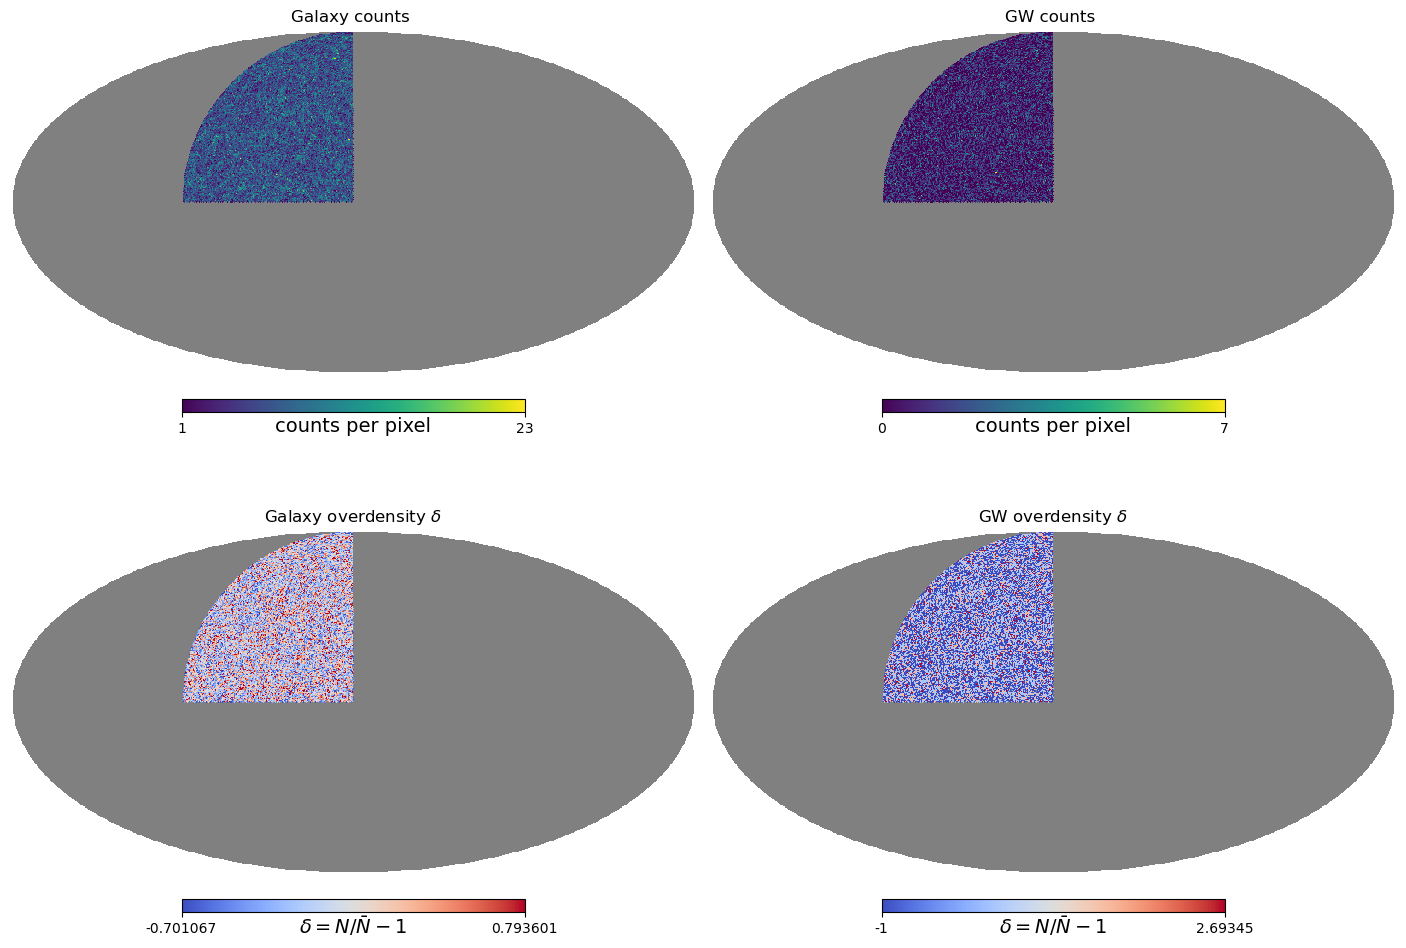

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

def plot_counts_and_overdensity_maps(
    galaxy_counts,
    gw_counts,
    delta_gal,
    delta_gw,
    mask,
    title_suffix="",
):
    # Hide pixels outside the observed footprint
    observed = mask > 0

    galaxy_counts_plot = galaxy_counts.copy().astype(float)
    gw_counts_plot = gw_counts.copy().astype(float)
    delta_gal_plot = delta_gal.copy().astype(float)
    delta_gw_plot = delta_gw.copy().astype(float)

    galaxy_counts_plot[~observed] = hp.UNSEEN
    gw_counts_plot[~observed] = hp.UNSEEN
    delta_gal_plot[~observed] = hp.UNSEEN
    delta_gw_plot[~observed] = hp.UNSEEN

    plt.figure(figsize=(14, 10))

    hp.mollview(
        galaxy_counts_plot,
        sub=(2, 2, 1),
        title=f"Galaxy counts {title_suffix}",
        unit="counts per pixel",
        cmap="viridis",
    )

    hp.mollview(
        gw_counts_plot,
        sub=(2, 2, 2),
        title=f"GW counts {title_suffix}",
        unit="counts per pixel",
        cmap="viridis",
    )

    hp.mollview(
        delta_gal_plot,
        sub=(2, 2, 3),
        title=f"Galaxy overdensity $\\delta$ {title_suffix}",
        unit=r"$\delta = N/\bar N - 1$",
        cmap="coolwarm",
        min=np.nanpercentile(delta_gal_plot[observed], 5),
        max=np.nanpercentile(delta_gal_plot[observed], 95),
    )

    hp.mollview(
        delta_gw_plot,
        sub=(2, 2, 4),
        title=f"GW overdensity $\\delta$ {title_suffix}",
        unit=r"$\delta = N/\bar N - 1$",
        cmap="coolwarm",
        min=np.nanpercentile(delta_gw_plot[observed], 5),
        max=np.nanpercentile(delta_gw_plot[observed], 95),
    )

    plt.show()   
    
plot_counts_and_overdensity_maps(
    galaxy_counts=galaxy_counts,
    gw_counts=gw_counts,
    delta_gal=delta_gal,
    delta_gw=delta_gw,
    mask=mask,
)


## 6. Creating NaMaster fields

Each field is constructed from an angular mask and an overdensity map:

```python
field_gal = nmt.NmtField(mask, [delta_gal])
field_gw = nmt.NmtField(mask, [delta_gw])
```

NaMaster uses the mask to correct for mode coupling caused by incomplete sky coverage.

---

## 7. Defining multipole bins

Because the survey mask couples neighbouring multipoles, the angular power spectra are measured in bins of width $\Delta\ell$. For each bin, NaMaster returns an effective multipole $\ell_{\mathrm{eff}}$, which is used when plotting the measured spectra. See Section 1.3 of https://namaster.readthedocs.io/en/latest/1BasicFunctionality.html for more information on this binning procedure.

---

## 8. Measuring the angular power spectra

The galaxy auto-spectrum is

\begin{align}
C_\ell^{\mathrm{g}\times \mathrm{g}}
=
\left\langle
\delta_{\mathrm{g},\ell m}
\delta_{\mathrm{g},\ell m}^{*}
\right\rangle.
\end{align}

The gravitational-wave auto-spectrum is

\begin{align}
C_\ell^{\mathrm{GW}\times \mathrm{GW}}
=
\left\langle
\delta_{\mathrm{GW},\ell m}
\delta_{\mathrm{GW},\ell m}^{*}
\right\rangle.
\end{align}

The cross-spectrum is

\begin{align}
C_\ell^{\mathrm{g}\times\mathrm{GW}}
=
\left\langle
\delta_{\mathrm{g},\ell m}
\delta_{\mathrm{GW},\ell m}^{*}
\right\rangle.
\end{align}

NaMaster estimates the masked pseudo-$C_\ell$, corrects for the mask-induced mode coupling, and returns the decoupled binned spectra. See Section 1.4 of https://namaster.readthedocs.io/en/latest/1BasicFunctionality.html for more info on pseudo spectra.

---

## 9. Shot noise

For a Poisson-sampled catalogue with mean angular number density $\bar n$, the auto-spectrum shot noise is approximately

\begin{align}
N_\ell = \frac{1}{\bar n},
\end{align}

where $\bar n$ is measured in objects per steradian. We subtract this contribution from the galaxy and gravitational-wave auto-spectra. For independent catalogues, there is normally no cross-shot-noise contribution. In this toy example, however, the gravitational-wave events are explicitly selected from the galaxy catalogue, so the two samples are not fully independent. If you do have a case like this, normally the shot noise is from the parent sample (in this case the galaxy catalogue).

---

In [ ]:

field_gal = nmt.NmtField( mask, [delta_gal])
field_gw = nmt.NmtField(mask, [delta_gw])

bins = nmt.NmtBin.from_nside_linear(nside, delta_ell)
ell_eff = bins.get_effective_ells()

cl_gal_gal = nmt.compute_full_master(field_gal, field_gal, bins)[0]
cl_gw_gw = nmt.compute_full_master(field_gw, field_gw, bins)[0]
cl_gal_gw = nmt.compute_full_master(field_gal, field_gw, bins)[0]

survey_area_sr = 4.0 * np.pi * fsky
nbar_gal = len(ra_gal) / survey_area_sr
nbar_gw = len(ra_gw) / survey_area_sr

shot_gal = 1.0 / nbar_gal
shot_gw = 1.0 / nbar_gw

cl_gal_gal_no_shot = cl_gal_gal - shot_gal
cl_gw_gw_no_shot = cl_gw_gw - shot_gw

# No independent Poisson cross-shot-noise term is subtracted here.
cl_gal_gw_no_shot = cl_gal_gw



## Plotting the results

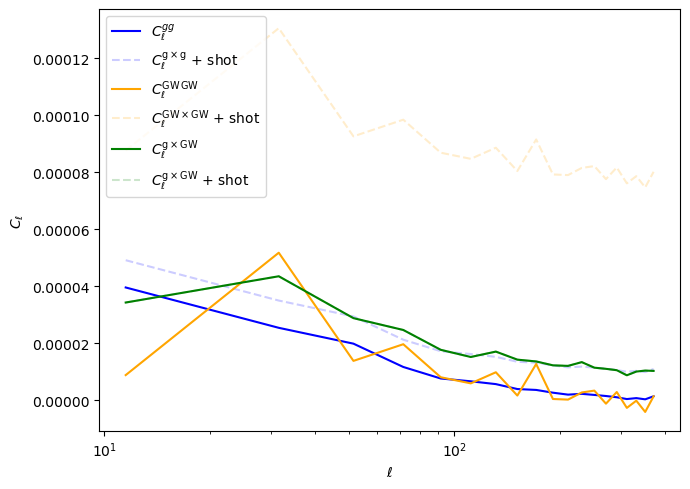

In [70]:

plt.figure(figsize=(7, 5))

plt.plot(ell_eff, cl_gal_gal_no_shot, label=r"$C_\ell^{gg}$", ls = '-', color = 'blue')
plt.plot(ell_eff, cl_gal_gal, label=r"$C_\ell^{\rm g\times g}$ + shot", ls = '--', color = 'blue', alpha = 0.2)

plt.plot(ell_eff, cl_gw_gw_no_shot, label=r"$C_\ell^{\rm GW\,GW}$", ls = '-', color = 'orange')
plt.plot(ell_eff, cl_gw_gw, label=r"$C_\ell^{\rm GW\times GW}$ + shot", ls = '--', color = 'orange', alpha = 0.2)

plt.plot(ell_eff, cl_gal_gw_no_shot, label=r"$C_\ell^{\rm g\times\rm GW}$", ls = '-', color = 'green')
plt.plot(ell_eff, cl_gal_gw, label=r"$C_\ell^{\rm g\times\rm GW}$ + shot", ls = '--', color = 'green', alpha = 0.2)


plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()